# F1 2025 Championship Winner Prediction

This notebook predicts the 2025 Formula 1 Drivers' Champion using the current 2025 standings plus historical seasons as context. It loads the dataset in `data/f1_championship_data.csv`, uses the ML pipeline in `src/ml_model.py`, and reports the most likely champion with supporting charts and a CSV of full probabilities.

In [1]:
# 1) Setup and imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we can import from src/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# Local modules
from ml_model import F1ChampionshipPredictor

# Display options
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")
sns.set_theme(style='whitegrid')

print('Project root:', project_root)
print('Using src path:', src_path)
print('Ready to go!')

Project root: g:\My Drive\Coding\Git Clones\MLF1
Using src path: g:\My Drive\Coding\Git Clones\MLF1\src
Ready to go!


In [6]:
# 2) Load data (historical + 2025 current standings)
DATA_PATH = os.path.join(project_root, 'data', 'f1_championship_data.csv')

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows across {df['year'].nunique()} seasons. Latest year: {df['year'].max()}")

# Peek at 2025 subset if present
if (df['year'] == 2025).any():
    display(df[df['year'] == 2025].head())
else:
    print("No 2025 rows found; notebook expects current-year standings in the CSV.")

# Basic sanity checks for required columns
required_cols = [
    'year','driver_id','driver_name','constructor_name','final_position','final_points',
    'wins','races_started','completion_rate','podiums','points_rate','avg_finish_position',
    'avg_grid_position','constructor_final_points','constructor_final_position'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in dataset: {missing}")

# Ensure ordering by year for feature engineering context
df = df.sort_values(['year','driver_id']).reset_index(drop=True)
df.tail(3)

Loaded 70 rows across 6 seasons. Latest year: 2025


,year,driver_id,driver_code,driver_name,nationality,constructor_id,constructor_name,final_position,final_points,wins,...,points_finishes,points_rate,dnfs,dnf_rate,fastest_laps,avg_finish_position,avg_grid_position,constructor_final_position,constructor_final_points,constructor_wins
49,2025,norris,NOR,Lando Norris,British,mclaren,McLaren,1,357,6,...,20,0.9520,0,0.0000,3,2.8000,2.5000,1,713,13
50,2025,piastri,PIA,Oscar Piastri,Australian,mclaren,McLaren,2,356,7,...,19,0.9050,0,0.0000,2,3.2000,3.8000,1,713,13
51,2025,verstappen,VER,Max Verstappen,Dutch,red_bull,Red Bull Racing,3,321,5,...,18,0.8570,0,0.0000,4,4.1000,2.1000,2,349,5
52,2025,russell,RUS,George Russell,British,mercedes,Mercedes,4,258,2,...,16,0.7620,0,0.0000,1,5.8000,4.9000,3,355,2
53,2025,leclerc,LEC,Charles Leclerc,Monegasque,ferrari,Ferrari,5,210,0,...,14,0.6670,0,0.0000,0,7.2000,6.4000,4,356,0


,year,driver_id,driver_code,driver_name,nationality,constructor_id,constructor_name,final_position,final_points,wins,...,points_finishes,points_rate,dnfs,dnf_rate,fastest_laps,avg_finish_position,avg_grid_position,constructor_final_position,constructor_final_points,constructor_wins
67,2025,stroll,STR,Lance Stroll,Canadian,aston_martin,Aston Martin,14,32,0,...,2,0.0950,0,0.0000,0,16.8000,17.1000,8,69,0
68,2025,tsunoda,TSU,Yuki Tsunoda,Japanese,red_bull,Red Bull Racing,17,28,0,...,1,0.0480,0,0.0000,0,18.1000,18.4000,2,349,5
69,2025,verstappen,VER,Max Verstappen,Dutch,red_bull,Red Bull Racing,3,321,5,...,18,0.8570,0,0.0000,4,4.1000,2.1000,2,349,5


In [7]:
# 3) Train or load the model
USE_PRETRAINED = True  # set False to retrain here (can be slow)
MODEL_PATH = os.path.join(project_root, 'models', 'f1_championship_predictor_2025.joblib')

predictor = F1ChampionshipPredictor()

if USE_PRETRAINED and os.path.exists(MODEL_PATH):
    predictor.load_model(MODEL_PATH)
    print('Loaded pretrained model from:', MODEL_PATH)
else:
    print('Training model (this may take a few minutes)...')
    results = predictor.train(df, optimize_hyperparameters=False)
    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    predictor.save_model(MODEL_PATH)
    print('Model trained and saved to:', MODEL_PATH)

assert predictor.is_trained, 'Model is not trained/loaded.'

INFO:ml_model:Model loaded from g:\My Drive\Coding\Git Clones\MLF1\models\f1_championship_predictor_2025.joblib
INFO:ml_model:Training timestamp: 2025-10-27 14:03:39.359584
INFO:ml_model:Training timestamp: 2025-10-27 14:03:39.359584


Loaded pretrained model from: g:\My Drive\Coding\Git Clones\MLF1\models\f1_championship_predictor_2025.joblib


In [8]:
# 4) Predict the 2025 champion from current standings
# We pass the full dataframe (historical + 2025) so the model can engineer features with context
predictions_2025 = predictor.predict_champion_probabilities_with_history(df)

# Save full table
results_dir = os.path.join(project_root, 'results')
os.makedirs(results_dir, exist_ok=True)
results_csv = os.path.join(results_dir, 'f1_2025_championship_predictions.csv')
predictions_2025.to_csv(results_csv, index=False)

# Show top 10
top10 = predictions_2025.head(10).copy()
champion_row = predictions_2025.iloc[0]

print('Predicted Champion:', champion_row['driver_name'], f"({champion_row['constructor_name']})")
print('Probability:', f"{champion_row['championship_probability']:.2%}")
print('Saved full predictions to:', results_csv)

display(top10)

INFO:feature_engineering_simple:Creating features for F1 championship prediction...
INFO:feature_engineering_simple:Created 34 features for ML model
INFO:feature_engineering_simple:Feature columns: ['final_position', 'final_points', 'wins', 'races_completed', 'races_started', 'completion_rate', 'podiums', 'podium_rate', 'points_finishes', 'points_rate', 'dnfs', 'dnf_rate', 'fastest_laps', 'avg_finish_position', 'avg_grid_position', 'constructor_final_position', 'constructor_final_points', 'constructor_wins', 'win_rate', 'points_per_race', 'podiums_per_race', 'fastest_laps_rate', 'points_vs_constructor', 'wins_vs_constructor', 'avg_position_improvement', 'position_consistency', 'reliability_score', 'dnf_penalty', 'team_strength', 'team_competitiveness', 'prev_year_position', 'prev_year_points', 'prev_year_wins', 'driver_experience']
INFO:feature_engineering_simple:Prediction data prepared: 21 samples, 34 features (2025 data only)
INFO:feature_engineering_simple:Created 34 features for M

Predicted Champion: Lando Norris (McLaren)
Probability: 39.78%
Saved full predictions to: g:\My Drive\Coding\Git Clones\MLF1\results\f1_2025_championship_predictions.csv


,driver_name,constructor_name,championship_probability,predicted_champion
13,Lando Norris,McLaren,0.3978,True
15,Oscar Piastri,McLaren,0.0994,False
20,Max Verstappen,Red Bull Racing,0.0686,False
16,George Russell,Mercedes,0.0230,False
12,Charles Leclerc,Ferrari,0.0171,False
9,Lewis Hamilton,Ferrari,0.0127,False
10,Nico Hulkenberg,Kick Sauber,0.0123,False
8,Isack Hadjar,RB,0.0121,False
0,Alexander Albon,Williams,0.0118,False
7,Pierre Gasly,Alpine,0.0111,False


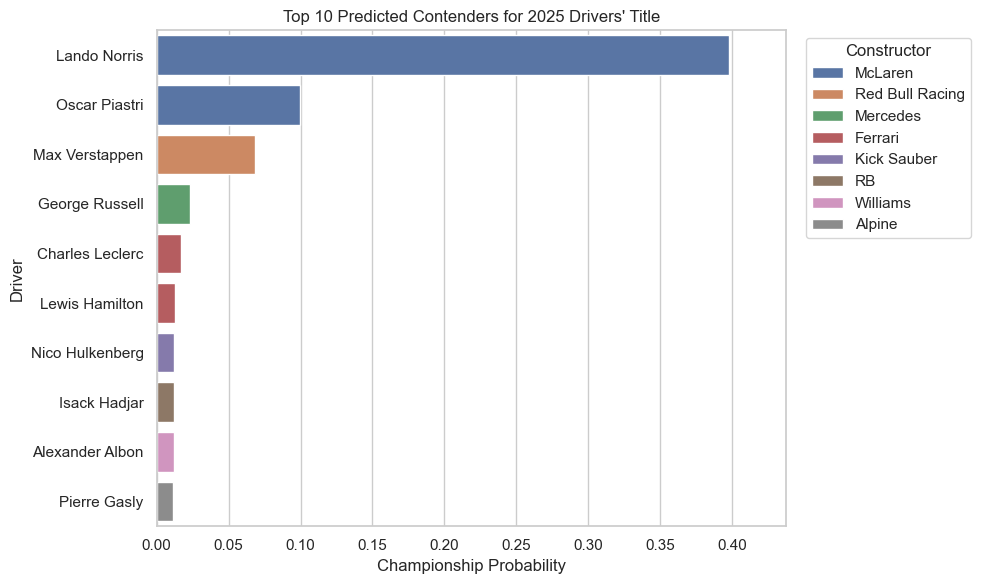

In [9]:
# 5) Visualize top contenders
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x='championship_probability',
    y='driver_name',
    hue='constructor_name',
    dodge=False
)
plt.xlabel('Championship Probability')
plt.ylabel('Driver')
plt.title('Top 10 Predicted Contenders for 2025 Drivers\' Title')
plt.xlim(0, max(0.4, float(top10['championship_probability'].max()) * 1.1))
plt.legend(title='Constructor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
Tips
---

- Set `USE_PRETRAINED = True` (default) to load the pre-trained ensemble in `models/f1_championship_predictor_2025.joblib`. Set to `False` to retrain (slower).
- The dataset used is `data/f1_championship_data.csv`. It must include rows for `year == 2025` (current standings) and prior seasons for context.
- Full predictions are saved to `results/f1_2025_championship_predictions.csv`.
- If you see import errors, make sure the notebook's working directory is the `notebooks/` folder so that `../src` is reachable via `project_root`.
- For deeper analysis (feature importances, evaluation), see `src/ml_model.py` and `src/model_evaluator.py`.